# Exploring for geothermal reservoirs

<div class="alert alert-block alert-warning">
<p class="lead"> <i class="fa fa-info-circle"></i> Instructions</p>

* In this notebook, you will find 8 questions with spaces to write your answers labelled *Your answer here*. Answers are either text or code depending on the question.
    
* Do this assignment by groups of 2, and rename the notebook *final-assignment_student-id-1_student-id-2.ipynb*, replacing *student-id-1* and *student-id-2* by your own student IDs.
    
* Submit only the notebook by **17 April 2026** [here](https://brightspace.tudelft.nl/d2l/lms/dropbox/user/folder_submit_files.d2l?db=162672&grpid=0&isprv=0&bp=0&ou=783027).
    
* Make sure that the entire notebook runs properly. If you encounter technical issues, you can reach out at G.Rongier@tudelft.nl
</div>

**Student names and IDs:**

*Your answer here*

### Imports

Let's start by importing the Python packages used during the unit:

In [87]:
# To manipulate arrays and matrices
import numpy as np
# To manipulate and analyze tabular data and time series
import pandas as pd
# To manipulate and analyze labelled multi-dimensional arrays
import xarray as xr
# To get some statistical functions
import scipy.stats as stats
# To create plots and visualizations
import matplotlib.pyplot as plt
# To use logarithmic scales in plots
import matplotlib.colors as mcolors
# To plot in 3D
import pyvista as pv
# To build 3D regular structured grids
from geomodpy.gridding.structured import build_regular_structured_grid
# To build 3D irregular structured grids
from geomodpy.gridding.structured import build_irregular_structured_grid
# To upscale well properties into structured grids
from geomodpy.upscaling import SampleUpscaler
# To create semivariogram models
from geomodpy.analysis.variography import Direction, VarioStruct, VarioModel
# To use GSLIB in Python
from geomodpy.wrapper.gslib import ExpVario, DECLUS, NSCORE, GAMV, KT3D, SGSIM, SISIM
# To use FLUVSIM in Python
from geomodpy.wrapper.fluvsim import FLUVSIM
# To use SNESIM in Python
from geomodpy.wrapper.snesim import SNESIM
# To plot semivariograms and slices from 3D grids
from geomodpy.plotting import plot_semivariogram, plot_3d_slices

Don't hesitate to import other packages or functions if you need them.

## 1. Introduction to the case study

A municipality is interested in building a geothermal plant to supply heat to its residents. An initial assessment of the legacy data available in the area led to the idendification of a potential reservoir that lies around 1500 m below the surface in a 30 m-thick interval of carbonate deposits. Based on the numerous legacy wells crossing this interval, 2 facies have been identified that strongly control reservoir properties:

1. **Matrix:** The original carbonate deposits, which show a very low permeability and are considered non-reservoir.  
2. **Fractures:** Fracture networks go through the carbonate deposits, which show a decent permeability and are considered potential targets.  

### Goal of this study

Your goal is to build a set of 3D numerical models of porosity and permeability in the reservoir to assess where to acquire new data and better characterize the potential of the reservoirs for heat production.

The domain of interest extends over 10 km by 10 km by 30 m in an area where deformations can be ignored. You only have access to the legacy well data, which include interpretations of the top and bottom horizons of the reservoir and interpretations of the facies along the wells. The 3D models should have 100 by 100 by 30 cells.

## 2. Facies modeling

**Question 1:** `1.5 points`  
Generate at least 10 facies realizations.

In [88]:
#Data loading 
well_data = pd.read_csv('data_final-assignment_wells.csv')

#Data description / explorations
print('Data sample (first 10 rows):')
print(well_data.head(10))

print(f'Number of wells: {well_data["Well_ID"].nunique()}')

print('\nSpatial extent:')
print(f'X range: {well_data["X"].min():.1f} - {well_data["X"].max():.1f} m')
print(f'Y range: {well_data["Y"].min():.1f} - {well_data["Y"].max():.1f} m') 
print(f'Z range: {well_data["Z"].min():.1f} - {well_data["Z"].max():.1f} m')
print(f'Thickness: {well_data["Z"].max()-well_data["Z"].min():.1f} m')

print('\nFacies analysis:')
facies_counts = well_data['Facies'].value_counts()
total_samples = len(well_data)
for facies, count in facies_counts.items():
    percentage = count / total_samples * 100
    print(f'  {facies}: {count:4d} samples ({percentage:5.1f}%)')


Data sample (first 10 rows):
   Well_ID       X       Y        Z     Facies  Porosity  Permeability
0        1  3180.0  7820.0 -1485.25  Fractures  0.072753     14.565073
1        1  3180.0  7820.0 -1485.50  Fractures  0.074373     13.971450
2        1  3180.0  7820.0 -1485.75  Fractures  0.073825     16.101683
3        1  3180.0  7820.0 -1486.00  Fractures  0.073397     14.559455
4        1  3180.0  7820.0 -1486.25  Fractures  0.070855     13.543171
5        1  3180.0  7820.0 -1486.50  Fractures  0.070908     11.545903
6        1  3180.0  7820.0 -1486.75  Fractures  0.068618     12.190801
7        1  3180.0  7820.0 -1487.00  Fractures  0.067246     11.362738
8        1  3180.0  7820.0 -1487.25  Fractures  0.066248     11.092890
9        1  3180.0  7820.0 -1487.50  Fractures  0.068201      9.702826
Number of wells: 32

Spatial extent:
X range: 460.0 - 9660.0 m
Y range: 820.0 - 9540.0 m
Z range: -1515.0 - -1485.2 m
Thickness: 29.8 m

Facies analysis:
  Fractures: 2759 samples ( 71.8%)
 

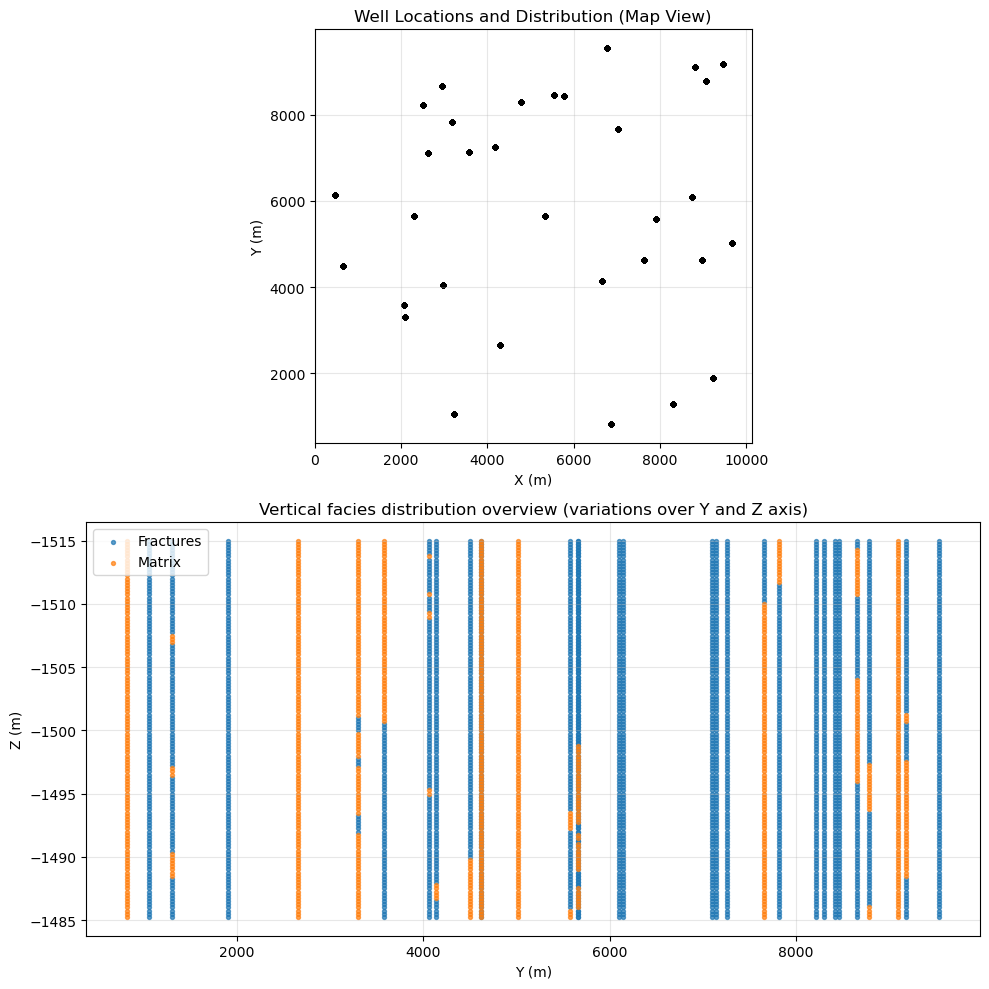

In [89]:
fig, axes = plt.subplots(2, 1, figsize=(10, 10))

# Plot 1: Well locations (map view)
scatter = axes[0].scatter(well_data['X'], well_data['Y'], c='black', alpha=0.8, s=8)
axes[0].set_xlabel('X (m)')
axes[0].set_ylabel('Y (m)')
axes[0].set_title('Well Locations and Distribution (Map View)')
axes[0].grid(True, alpha=0.3)
axes[0].set_aspect('equal')



# Plot 2: Vertical facies distribution overview (variations over Y and Z axis)
for facies in well_data['Facies'].unique():
    subset = well_data[well_data['Facies'] == facies]
    axes[1].scatter(subset['Y'], subset['Z'], label=facies, alpha=0.7, s=8)
axes[1].set_xlabel('Y (m)')
axes[1].set_ylabel('Z (m)')
axes[1].set_title('Vertical facies distribution overview (variations over Y and Z axis)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

In [90]:
# Building 3D grid: 10km x 10km x 30m with 100 x 100 x 30 cells

# Defining domain parameters based on well data extent and requirements
x_min, x_max = 0., 10000.  # 10 km domain
y_min, y_max = 0., 10000.  # 10 km domain  
z_min, z_max = -1530., -1500.  # 30 m thick reservoir

# Grid dimensions: 100x100x30 cells
nx, ny, nz = 100, 100, 30
spacing_x = (x_max - x_min) / nx  # 100 m
spacing_y = (y_max - y_min) / ny  # 100 m  
spacing_z = (z_max - z_min) / nz  # 1 m

# Building regular structured grid (reference: Practical 10 - Carbonate reservoir case study)
grid = build_regular_structured_grid(
    shape=(nx, ny, nz),
    spacing=(spacing_x, spacing_y, spacing_z),
    origin=(x_min + spacing_x/2, y_min + spacing_y/2, z_min + spacing_z/2)
)

print(f"Domain size: {(x_max-x_min)/1000:.0f} km x {(y_max-y_min)/1000:.0f} km x {(z_max-z_min):.0f} m")
print(f"Grid dimensions: {nx} x {ny} x {nz} cells")
print(f"Total cells: {nx*ny*nz:,}")


Domain size: 10 km x 10 km x 30 m
Grid dimensions: 100 x 100 x 30 cells
Total cells: 300,000


In [91]:
# Converting facies to numerical codes and upscaling to grid
facies_map = {'Matrix': 0, 'Fractures': 1}
well_data['Facies_code'] = well_data['Facies'].map(facies_map)

# Upscaling well data to grid using mode aggregation
upscaler = SampleUpscaler(grid)
well_data_up = upscaler.resample(
    well_data[['X', 'Y', 'Z']], 
    well_data[['Facies_code']],
    agg='mode'
)

print(f"Well data upscaled = {len(well_data)} become {len(well_data_up)} samples")
facies_dist = well_data_up['Facies_code'].value_counts().sort_index()
print(f"Facies distribution = Matrix: {facies_dist[0]}, Fractures: {facies_dist[1]} samples")

Well data upscaled = 3840 become 491 samples
Facies distribution = Matrix: 128, Fractures: 363 samples


In [92]:
# Experimental variogram calculation
directions = []
for azimuth in [0., 45., 90., 135.]:
    directions += [Direction(azimuth=azimuth,
                             azimuth_tolerance=45.,
                             horizontal_bandwidth=1000.,
                             dip_tolerance=45.,
                             vertical_bandwidth=30.,
                             n_lags=6,
                             lag_separation_distance=500.)]
    
directions += [Direction(azimuth=0.,
                         azimuth_tolerance=90.,
                         horizontal_bandwidth=3000.,
                         dip=90.,
                         dip_tolerance=22.5,
                         vertical_bandwidth=30.,
                         n_lags=5,
                         lag_separation_distance=1.5)]

gamv = GAMV(well_data_up,
            coord_columns=('X', 'Y', 'Z'),
            exp_vario=[ExpVario('Facies_code', 'Facies_code', 10, 0),
                       ExpVario('Facies_code', 'Facies_code', 10, 1)],
            direction=directions)
exp_vario = gamv.run()


GAMV Version: 3.000

data file = gamv_1_data.dat
columns for X,Y,Z =            1           2           3
number of variables =            1
columns =            7
trimming limits =   -1.00000002E+21   1.00000002E+21
output file = gamv_1.out
number of lags =            5
lag distance =    1.50000000
lag tolerance =   0.990000010
number of directions =            1
azm, atol, bandwh =    0.00000000       90.0000000       3000.00000
dip, dtol, bandwd =    90.0000000       22.5000000       30.0000000
flag to standardize sills =            1
number of variograms =            2
tail,head,type =            1           1          10
indicator threshold =    0.00000000
tail,head,type =            1           1          10
indicator threshold =    1.00000000

maxdat =          491
Variable number            1
Number   =          491
Average  =   0.739307523
Variance =   0.192731902

Variogram  1 Indicator 1/2 Variogram:  tail=Indicator  1 head=Indicator  1
Variogram  2 Indicator 1/2 Variogram:

In [93]:
# Matrix Variogram models 
vario_model_1 = VarioModel(nugget_effect=0.,
                           structures=VarioStruct(model='exponential',
                                                  partial_sill=0.9,
                                                  azimuth=0.,
                                                  dip=0.,
                                                  plunge=0.,
                                                  range_hmax=1200.,
                                                  range_hmin=1000.,
                                                  range_vert=22.5))

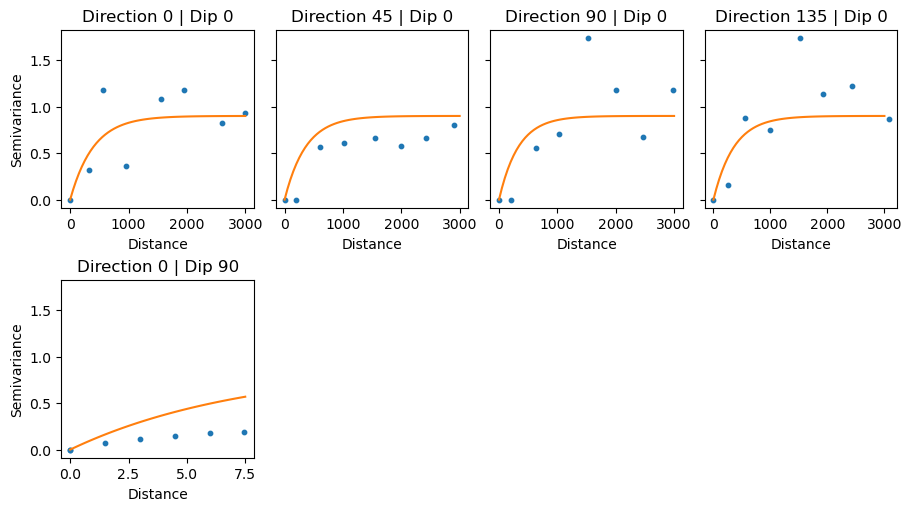

In [94]:
# Matrix variogram validation  
vario_model_values = vario_model_1.semivario(direction=directions)
plot_semivariogram(directions, exp_vario[exp_vario['Tail'] == 'Indicator 1'], vario_model_values)

In [95]:
# Fractures Variogram Model
vario_model_2 = VarioModel(nugget_effect=0.05,
                           structures=VarioStruct(model='exponential',
                                                  partial_sill=0.75,
                                                  azimuth=45.,
                                                  dip=0.,
                                                  plunge=0.,
                                                  range_hmax=600.,
                                                  range_hmin=300.,
                                                  range_vert=25.))
vario_model_values = vario_model_2.semivario(direction=directions)

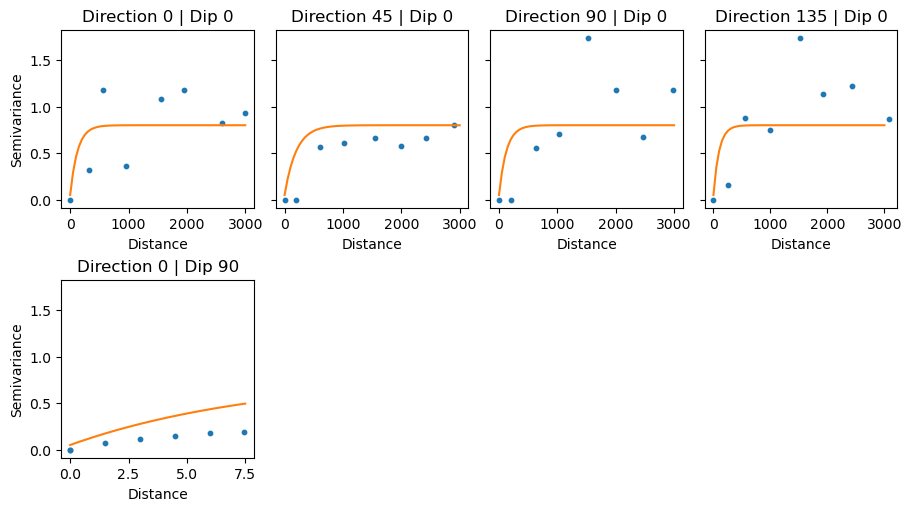

In [96]:
# Fractures variogram validation - Following Notebook 6 format
plot_semivariogram(directions, exp_vario[exp_vario['Tail'] == 'Indicator 2'], vario_model_values)

In [97]:
# Generating 10 facies realizations using SISIM
sisim = SISIM(
    vario_model=[vario_model_1, vario_model_2],  # Matrix and Fractures models
    data=well_data_up,
    coord_columns=('X', 'Y', 'Z'),
    data_column='Facies_code',
    shape=(100, 100, 30),
    spacing=(100., 100., 1.),
    origin=(0., 0., -1515.),
    n_realizations=10,
    seed=42
)

facies_results = sisim.run()
grid['Facies'] = facies_results['Class']

print(f"Generated {facies_results['Class'].shape[0]} facies realizations")

# Check facies proportions in first realization
real_0 = facies_results['Class'][0].values.flatten()
unique, counts = np.unique(real_0, return_counts=True)

props = counts / len(real_0)
print(f"Realization 1 proportions: Matrix={props[0]:.3f}, Fractures={props[1]:.3f}")


SISIM Version: 3.000

variable type (1=continuous, 0=categorical)=            0
number of thresholds / categories =            2
thresholds / categories =    0.00000000       1.00000000
global cdf / pdf        =   0.750000000      0.250000000
data file = sisim_data.dat
input columns =            1           2           3           7
soft data file = None
trimming limits        -1.00000002E+21   1.00000002E+21
data limits (tails)     0.00000000       1.00000000
lower tail =            1   0.00000000
middle =            1   0.00000000
upper tail =            1   1.00000000
file for tab. quant. sisim_tabulated_data.dat
columns for vr wt =            7           0
debugging level =            0
debugging file = sisim.dbg
output file = sisim.out
number of simulations =           10
X grid specification =          100   0.00000000       100.000000
Y grid specification =          100   0.00000000       100.000000
Z grid specification =           30  -1515.00000       1.00000000
random number

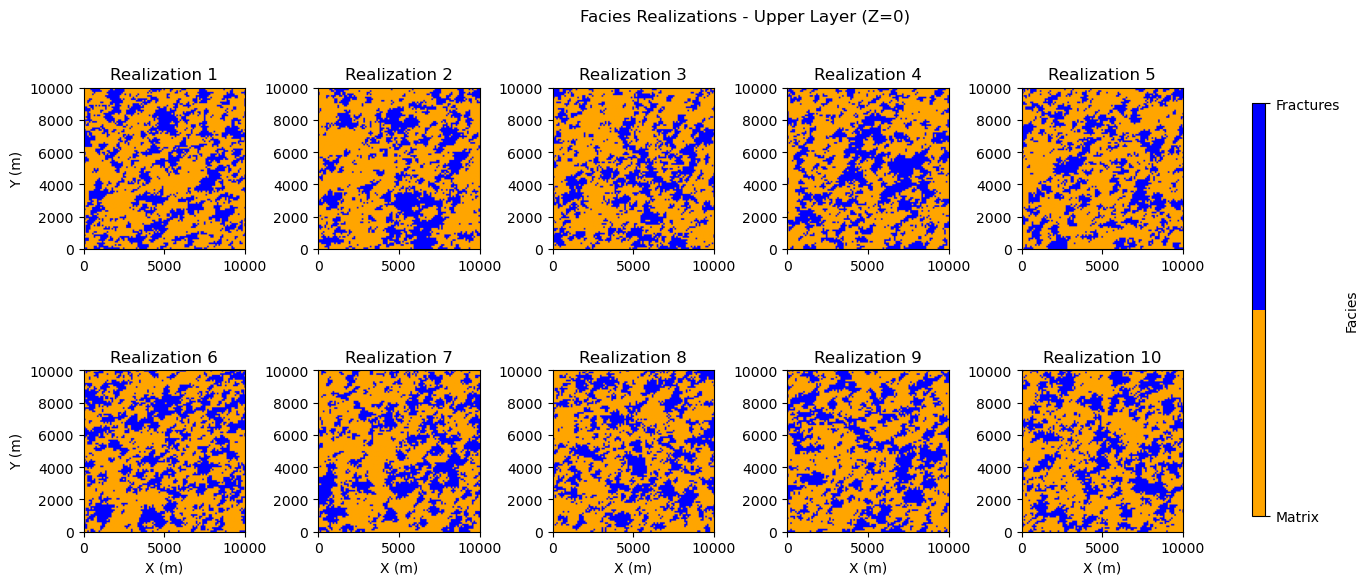

In [98]:
# Visualizing facies realizations in the upper part layer (Z=0)
from matplotlib.colors import ListedColormap
facies_colors = ListedColormap(['orange', 'blue'])  # Matrix=orange, Fractures=blue

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()

for i in range(10):
    # Showing top layer slice (Z=0)
    facies_slice = grid['Facies'][i, :, :, 0].values
    im = axes[i].imshow(facies_slice, cmap=facies_colors, vmin=0, vmax=1, 
                        origin='lower', extent=[0, 10000, 0, 10000])
    axes[i].set_title(f'Realization {i+1}')
    axes[i].set_xlabel('X (m)') if i >= 5 else None
    axes[i].set_ylabel('Y (m)') if i % 5 == 0 else None

plt.tight_layout()
plt.suptitle('Facies Realizations - Upper Layer (Z=0)', y=1.02)
cbar = fig.colorbar(im, ax=axes, shrink=0.8, aspect=30)
cbar.set_label('Facies')
cbar.set_ticks([0, 1])
cbar.set_ticklabels(['Matrix', 'Fractures'])
plt.show()

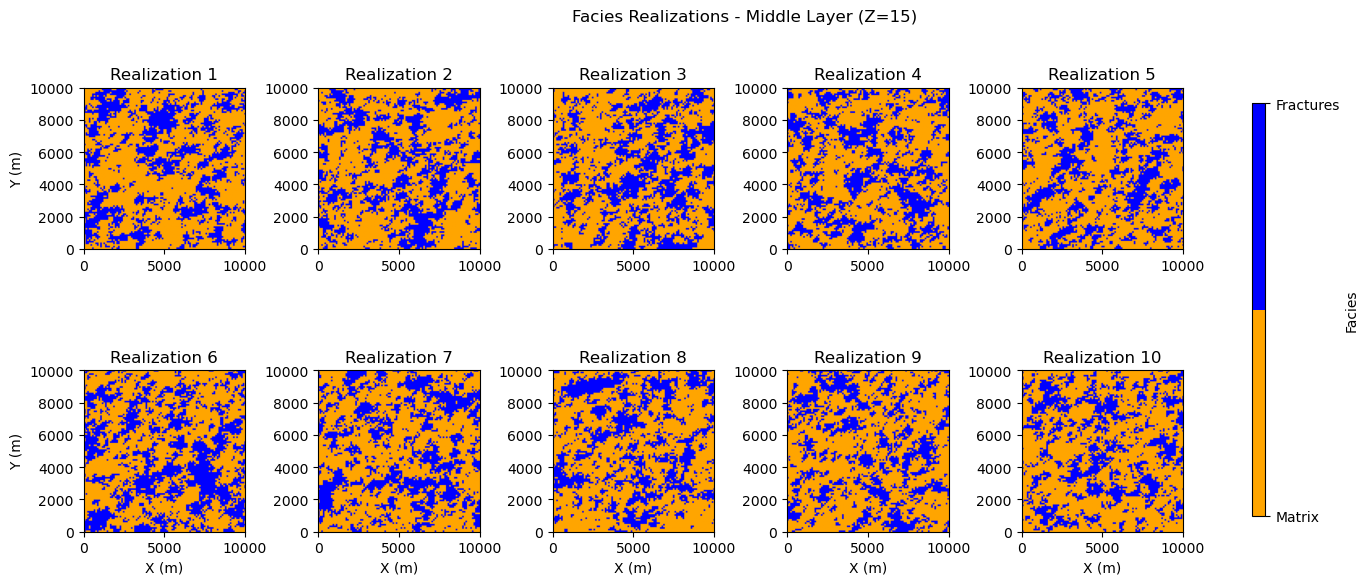

In [99]:
# Visualizing facies realizations in the middle layer (Z=15) 
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()

for i in range(10):
    # Showing middle layer slice (Z=15)
    facies_slice = grid['Facies'][i, :, :, 15].values
    im = axes[i].imshow(facies_slice, cmap=facies_colors, vmin=0, vmax=1, 
                        origin='lower', extent=[0, 10000, 0, 10000])
    axes[i].set_title(f'Realization {i+1}')
    axes[i].set_xlabel('X (m)') if i >= 5 else None
    axes[i].set_ylabel('Y (m)') if i % 5 == 0 else None

plt.tight_layout()
plt.suptitle('Facies Realizations - Middle Layer (Z=15)', y=1.02)
cbar = fig.colorbar(im, ax=axes, shrink=0.8, aspect=30)
cbar.set_label('Facies')
cbar.set_ticks([0, 1])
cbar.set_ticklabels(['Matrix', 'Fractures'])
plt.show()

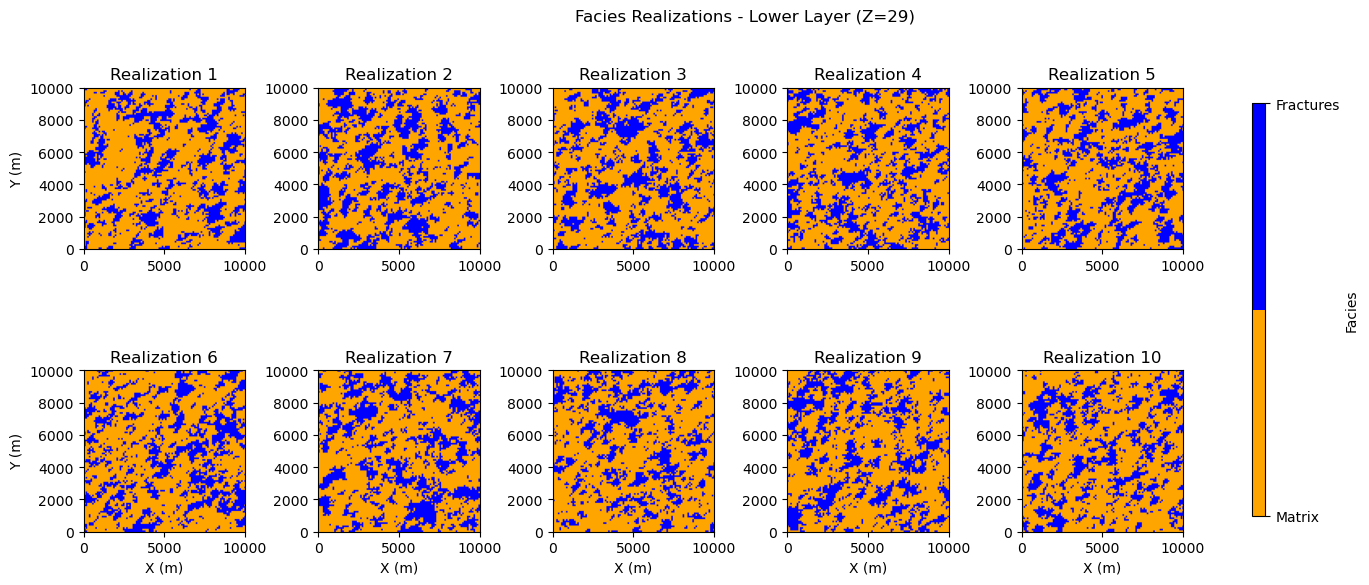

In [100]:
# Visualizing facies realizations in the lower layer (Z=29)
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()

for i in range(10):
    # Showing bottom layer slice (Z=29)
    facies_slice = grid['Facies'][i, :, :, 29].values
    im = axes[i].imshow(facies_slice, cmap=facies_colors, vmin=0, vmax=1, 
                        origin='lower', extent=[0, 10000, 0, 10000])
    axes[i].set_title(f'Realization {i+1}')
    axes[i].set_xlabel('X (m)') if i >= 5 else None
    axes[i].set_ylabel('Y (m)') if i % 5 == 0 else None

plt.tight_layout()
plt.suptitle('Facies Realizations - Lower Layer (Z=29)', y=1.02)
cbar = fig.colorbar(im, ax=axes, shrink=0.8, aspect=30)
cbar.set_label('Facies')
cbar.set_ticks([0, 1])
cbar.set_ticklabels(['Matrix', 'Fractures'])
plt.show()

**Question 2:** `1.5 points`  
Explain the different steps you have followed and justify the methods you have used.

The following three (3) steps are performed for facies modeling:

**1. Data Preparation:**
- Loaded legacy well data and converted categorical facies (Matrix/Fractures) to numerical codes (0 = Matrix; 1 = Fractures).
- Built 100 × 100 × 30 grid covering 10 km × 10 km × 30 m domain with 100 m horizontal and 1 m vertical resolution.
- Upscaled well data to grid using mode aggregation. Mode is used since the data has categorical / discrete data.

**2. Variogram Modeling:**

*2a. Matrix facies parameters:*
- Nugget effect = 0 (no micro-scale variability, matrix is continuous).
- Exponential model (gradual correlation decay, typical for geological continuity).
- Partial sill = 0.9 (high variance, matrix shows strong spatial structure).
- Azimuth = 0° (no preferred orientation, isotropic background).
- Ranges: horizontal 1000-1200m, vertical 22.5m (wide lateral continuity, limited vertical due to thin reservoir).

*2b. Fractures facies parameters:*
- Nugget effect = 0.05 (small local variability in fracture networks).  
- Exponential model (similar geological reasoning as matrix).
- Partial sill = 0.75 (moderate variance, fractures less structured than matrix).
- Azimuth = 45° (preferred fracture orientation, likely structural control).
- Ranges: horizontal 300-600m, vertical 25m (smaller patches, anisotropic pattern).

**3. SISIM Simulation:**

*Justification:* SISIM (Sequential Indicator Simulation) was chosen because it is specifically designed for categorical/discrete facies data with discrete classes. Unlike continuous methods (SGSIM), SISIM works with indicator functions that preserve categorical nature of facies. It ensures exact reproduction of facies at well locations while maintaining global facies proportions from the upscaled dataset.

In the simmulation, we conducted and maintained:
- Sequential Indicator Simulation for 2-category data (Matrix=0, Fractures=1).
- 10 realizations to quantify spatial uncertainty (as what in the assignment).
- Seed = 42, for reproducible results. 
- Preserving facies proportions (Matrix ~26%, Fractures ~74% from upscaled data).

## 3. Porosity modeling

**Question 3:** `1.5 points`  
Generate at least 10 porosity realizations.

In [101]:
# Upscale porosity data 
well_data_up = upscaler.resample(well_data[['X', 'Y', 'Z']],
                                 well_data[['Facies_code', 'Porosity', 'Permeability']],
                                 agg=['mode', 'mean', 'gmean'])

In [120]:
# Start with the first facies (Facies_code = 0)
facies_data_up = well_data_up[well_data_up['Facies_code'] == 0].copy()

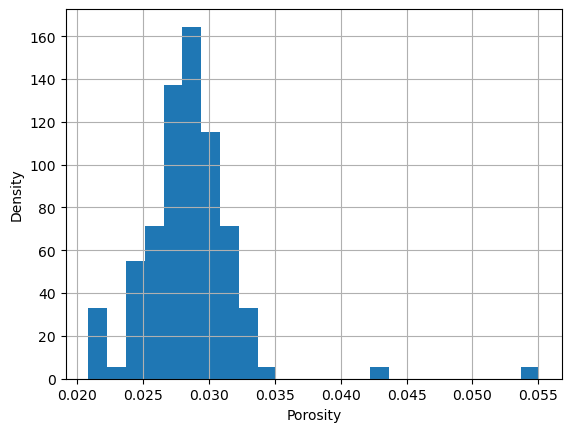

In [121]:
# Plot the data to check the distribution 
fig, ax = plt.subplots()
facies_data_up['Porosity'].hist(ax=ax, bins='auto', density=True)
ax.set(xlabel='Porosity', ylabel='Density');

In [122]:
# Normalise the data
nscore = NSCORE(facies_data_up, data_columns='Porosity')
facies_data_up, trans_table = nscore.run()


NSCORE Version: 3.000

data file = nscore_distrib.dat
columns =            8           0
trimming limits =   -1.00000002E+21   1.00000002E+21
consider a different ref. dist. (1=yes) =            0
file with reference distribution = None
columns =            1           0
file for output = nscore.out
file for transformation table = nscore.trn

NSCORE Version: 3.000 Finished




In [123]:
# Define a semivariogram model
gamv = GAMV(facies_data_up,
            coord_columns=('X', 'Y', 'Z'),
            exp_vario=ExpVario('NS:Porosity', 'NS:Porosity', 1),
            direction=directions)
exp_vario = gamv.run()


GAMV Version: 3.000

data file = gamv_1_data.dat
columns for X,Y,Z =            1           2           3
number of variables =            1
columns =           10
trimming limits =   -1.00000002E+21   1.00000002E+21
output file = gamv_1.out
number of lags =            5
lag distance =    1.50000000
lag tolerance =   0.990000010
number of directions =            1
azm, atol, bandwh =    0.00000000       90.0000000       3000.00000
dip, dtol, bandwd =    90.0000000       22.5000000       30.0000000
flag to standardize sills =            1
number of variograms =            1
tail,head,type =            1           1           1

maxdat =          128
Variable number            1
Number   =          128
Average  =    0.00000000
Variance =   0.990051389

Variogram  1 Semivariogram          :  tail=NS:Porosity  head=NS:Porosity
currently on        12 of       128
currently on        24 of       128
currently on        36 of       128
currently on        48 of       128
currently on        

In [129]:
vario_model = VarioModel(nugget_effect=0.,
                         structures=VarioStruct(model='exponential',
                                                partial_sill=1.,
                                                azimuth=45.,
                                                dip=0.,
                                                plunge=0.,
                                                range_hmax=5000.,
                                                range_hmin=2000.,
                                                range_vert=30.))
vario_model_values = vario_model.semivario(direction=directions)

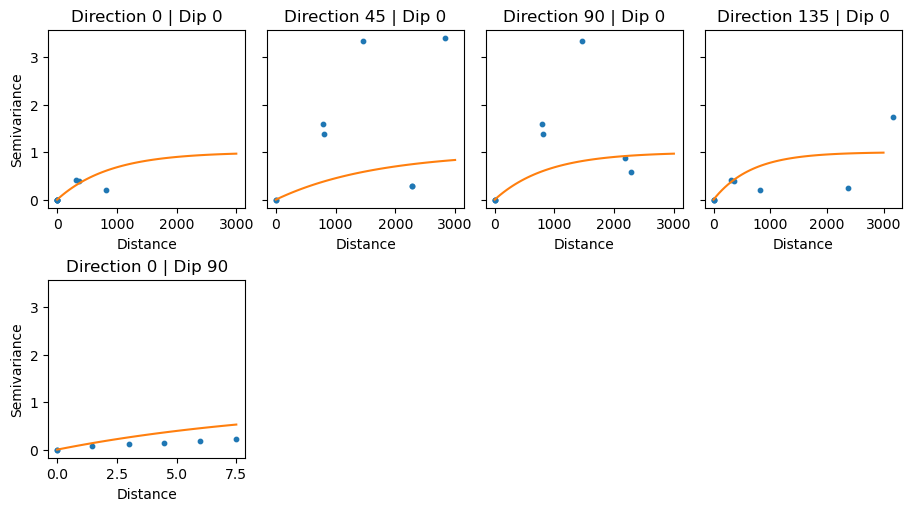

In [130]:
plot_semivariogram(directions, exp_vario, vario_model_values)

In [126]:
sgsim = SGSIM(vario_model=vario_model,
              data=facies_data_up,
              coord_columns=('X', 'Y', 'Z'),
              data_columns='Porosity',
              shape=(100, 100, 30),
              spacing=(100., 100., 1.),
              origin=(0., 0., -1515.),
              n_realizations=10,
              transform_data=True,
              seed=42)

grid['Porosity_0'] = sgsim.run()['Variable']


SGSIM Version: 3.001

data file = sgsim_data.dat
input columns =            1           2           3           8           0           0
trimming limits =   -1.00000002E+21   1.00000002E+21
transformation flag =            1
transformation file = sgsim.trn
consider smoothed distribution (1=yes) =            0
file with smoothed distribution = None
columns =            1           0
data limits (tails) =    2.08609626E-02   5.50738983E-02
lower tail =            1   2.08609626E-02
upper tail =            1   5.50738983E-02
debugging level =            0
debugging file = sgsim.dbg
output file sgsim.out
number of realizations =           10
X grid specification =          100   0.00000000       100.000000
Y grid specification =          100   0.00000000       100.000000
Z grid specification =           30  -1515.00000       1.00000000
random number seed =           42
min and max data =            0           8
maximum previous nodes =           12
two-part search flag =            1
mu

In [131]:
# Then the second facies (Facies_code = 1)
facies_data_up = well_data_up[well_data_up['Facies_code'] == 1].copy()

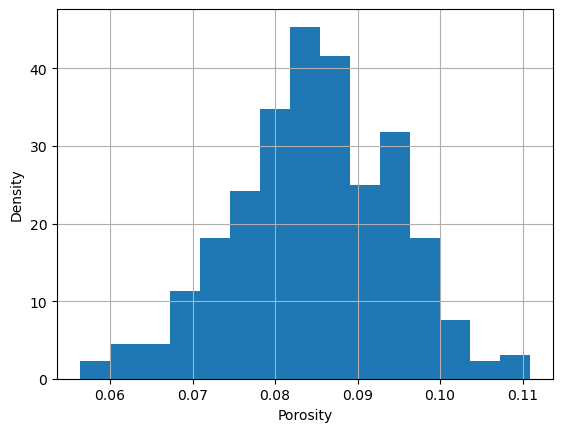

In [132]:
# Plot the data to check the distribution 
fig, ax = plt.subplots()
facies_data_up['Porosity'].hist(ax=ax, bins='auto', density=True)
ax.set(xlabel='Porosity', ylabel='Density');

In [133]:
# Normalise the data
nscore = NSCORE(facies_data_up, data_columns='Porosity')
facies_data_up, trans_table = nscore.run()


NSCORE Version: 3.000

data file = nscore_distrib.dat
columns =            8           0
trimming limits =   -1.00000002E+21   1.00000002E+21
consider a different ref. dist. (1=yes) =            0
file with reference distribution = None
columns =            1           0
file for output = nscore.out
file for transformation table = nscore.trn

NSCORE Version: 3.000 Finished




In [134]:
# Define a semivariogram model
gamv = GAMV(facies_data_up,
            coord_columns=('X', 'Y', 'Z'),
            exp_vario=ExpVario('NS:Porosity', 'NS:Porosity', 1),
            direction=directions)
exp_vario = gamv.run()


GAMV Version: 3.000

data file = gamv_1_data.dat
columns for X,Y,Z =            1           2           3
number of variables =            1
columns =           10
trimming limits =   -1.00000002E+21   1.00000002E+21
output file = gamv_1.out
number of lags =            5
lag distance =    1.50000000
lag tolerance =   0.990000010
number of directions =            1
azm, atol, bandwh =    0.00000000       90.0000000       3000.00000
dip, dtol, bandwd =    90.0000000       22.5000000       30.0000000
flag to standardize sills =            1
number of variograms =            1
tail,head,type =            1           1           1

maxdat =          363
Variable number            1
Number   =          363
Average  =    0.00000000
Variance =   0.996448934

Variogram  1 Semivariogram          :  tail=NS:Porosity  head=NS:Porosity
currently on        36 of       363
currently on        72 of       363
currently on       108 of       363
currently on       144 of       363
currently on       1

In [140]:
vario_model = VarioModel(nugget_effect=0.,
                         structures=VarioStruct(model='exponential',
                                                partial_sill=1.,
                                                azimuth=45.,
                                                dip=0.,
                                                plunge=0.,
                                                range_hmax=5000.,
                                                range_hmin=2000.,
                                                range_vert=30.))
vario_model_values = vario_model.semivario(direction=directions)

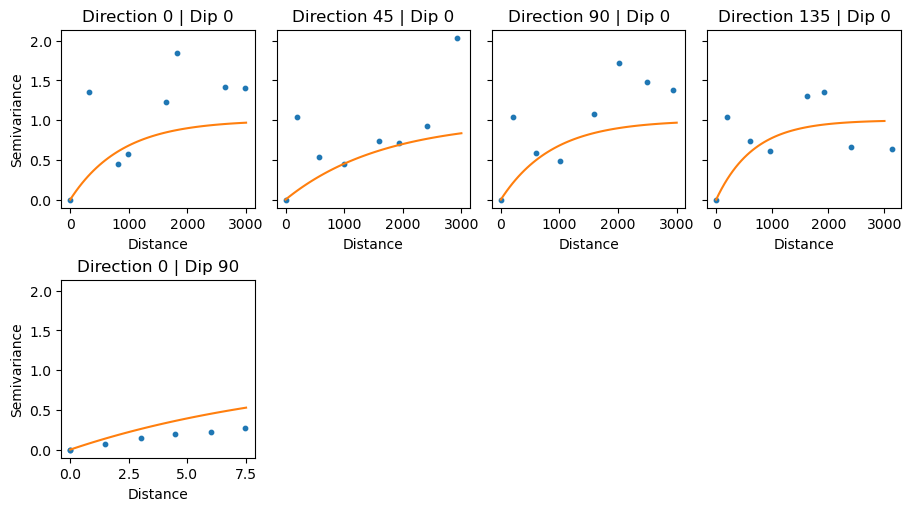

In [141]:
plot_semivariogram(directions, exp_vario, vario_model_values)

In [137]:
sgsim = SGSIM(vario_model=vario_model,
              data=facies_data_up,
              coord_columns=('X', 'Y', 'Z'),
              data_columns='Porosity',
              shape=(100, 100, 30),
              spacing=(100., 100., 1.),
              origin=(0., 0., -1515.),
              n_realizations=10,
              transform_data=True,
              seed=42)

grid['Porosity_1'] = sgsim.run()['Variable']


SGSIM Version: 3.001

data file = sgsim_data.dat
input columns =            1           2           3           8           0           0
trimming limits =   -1.00000002E+21   1.00000002E+21
transformation flag =            1
transformation file = sgsim.trn
consider smoothed distribution (1=yes) =            0
file with smoothed distribution = None
columns =            1           0
data limits (tails) =    5.63098080E-02  0.110958911
lower tail =            1   5.63098080E-02
upper tail =            1  0.110958911
debugging level =            0
debugging file = sgsim.dbg
output file sgsim.out
number of realizations =           10
X grid specification =          100   0.00000000       100.000000
Y grid specification =          100   0.00000000       100.000000
Z grid specification =           30  -1515.00000       1.00000000
random number seed =           42
min and max data =            0           8
maximum previous nodes =           12
two-part search flag =            1
multiple g

In [116]:
# Combine the porosities 
grid['Porosity'] = grid['Porosity_0'].copy()
grid['Porosity'].values[grid['Facies'] == 1] = grid['Porosity_1'].values[grid['Facies'] == 1]

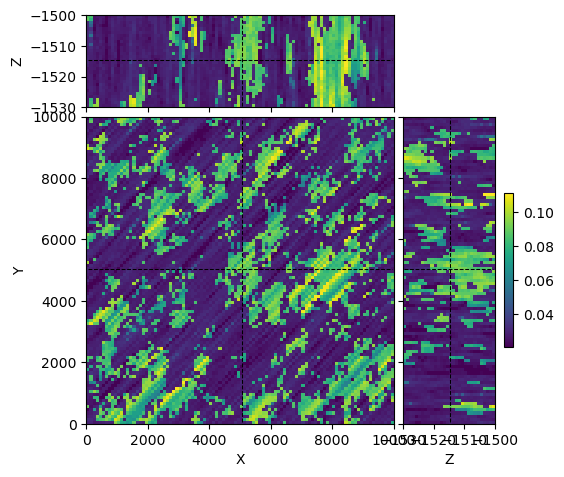

In [117]:
# Plot the results 
plot_3d_slices(grid['Porosity'], 0)

In [118]:
#p = pv.Plotter()

# Create a PyVista grid for plotting
#pv_grid = pv.StructuredGrid(grid['X_nodes'].to_numpy(),
#                            grid['Y_nodes'].to_numpy(),
#                            grid['Z_nodes'].to_numpy())
# Plot the grid colored by the sandstone proportion
#p.add_mesh(pv_grid, scalars=grid['Porosity'][0].to_numpy().T.ravel())
# Add some vertical exaggeration
#p.set_scale(zscale=10)

#p.show()

**Question 4:** `1.5 points`  
Explain the different steps you have followed and justify the methods you have used.

The porosity modeling follows the work flow from notebook 10. case study carbonate reservoir, as we are also dealing with a carbonate reservoir in this assignment. We first upscaled the data, using 'mean' for porosity as this is a continuous variable so we want the average in each block. We used 'gmean' (geometric mean) for permeability as the hterogeneity is not layered.

We followed the same work flow for both facies independently. We start with facies code 0 and follow the steps described below. We did steps 1-5 for each facies and then combned them in step 6. 

**Step 1 - extract the data for either facies 1 or 2**

**Step 2 - check the distribution of the porosity data**
If the data is not normaly distributed we normalise it so that we can use Gaussian processes further down the line. 

**Step 3 - define a semivariogram model**
As the data points are in the same location as for the facies in the previous assignment we can keep the directions the same. 

**Step 5 - run the realisations using SGSIM**
We then use the semi variogram model as the input for the SGSIM model where the parameters shape, spacing and origin are the same as for the facies as the data is at the same locations and we want to calculate the porosity over the same grid. We use SGSIM instead of SISIM as we are now modeling a continuous variable instead of a categorial one like for the facies. We generate 10 realisations of the porosity. 

**Step 6 - combine the porosities and plot results**
We then combine the porosities for each facies into one single porosity grid and visualise the results to see if there are any obvious errors. 

## 4. Permeability modeling

**Question 5:** `1.5 points`  
Generate at least 10 permeability realizations.

In [119]:
# Your answer here

**Question 6:** `1.5 points`  
Explain the different steps you have followed and justify the methods you have used.

*Your answer here*

## 5. Outcomes of the study

**Question 7:** `0.5 points`  
Based on your models, where would you advise to drill a new vertical well? Provide approximate $(x, y)$ coordinates and justify your answer.

*Your answer here*

**Question 8:** `0.5 points`  
What would you propose to improve the models, beside gathering more data?

*Your answer here*